In [ ]:
# desinstala as versões conflitantes atuais do ambiente
!pip uninstall -y numpy scikit-surprise

# força a instalação do NumPy em uma versão antiga compatível com o Surprise
!pip install numpy==1.26.4

# reinstala o scikit-surprise para ele se alinhar com o NumPy
!pip install scikit-surprise

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 

  Using cached scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl
^C


In [ ]:
# importes necessarias
import pandas as pd # manipulação e análise de dados
import numpy as np # operações matemáticas e manipulação de arrays
import matplotlib.pyplot as plt # criação de gráficos e visualizações básicas
import seaborn as sns # visualização de dados estatísticos baseada no matplotlib
from surprise import Dataset, Reader, SVD, KNNBaseline # classes para carregar os dados e os algoritmos
from surprise.model_selection import cross_validate, train_test_split# utilitários para validação cruzada e divisão de treino e teste
from surprise import accuracy # métricas para calcular o erro das previsões
from collections import defaultdict # estrutura para agrupar as recomendações por usuário

In [ ]:
# leitura do arquivo csv da steam definindo os nomes das colunas manualmente
df = pd.read_csv('steam-200k.csv', header=None, names=['user_id', 'game_title', 'behavior', 'hours_played', 'Resto'])

# exibe a quantidade de linhas e colunas do dataframe para verificação
print(df.shape)

# mostra as 10 primeiras linhas da tabela para inspecionar os dados
df.head(10)

(200000, 5)


,user_id,game_title,behavior,hours_played,Resto
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0,0
1,151603712,The Elder Scrolls V Skyrim,play,273.0,0
2,151603712,Fallout 4,purchase,1.0,0
3,151603712,Fallout 4,play,87.0,0
4,151603712,Spore,purchase,1.0,0
5,151603712,Spore,play,14.9,0
6,151603712,Fallout New Vegas,purchase,1.0,0
7,151603712,Fallout New Vegas,play,12.1,0
8,151603712,Left 4 Dead 2,purchase,1.0,0
9,151603712,Left 4 Dead 2,play,8.9,0


Tipos de comportamento: <ArrowStringArray>
['purchase', 'play']
Length: 2, dtype: str

Número de usuários únicos: 12393
Número de jogos únicos: 5155
Total de registros: 200000


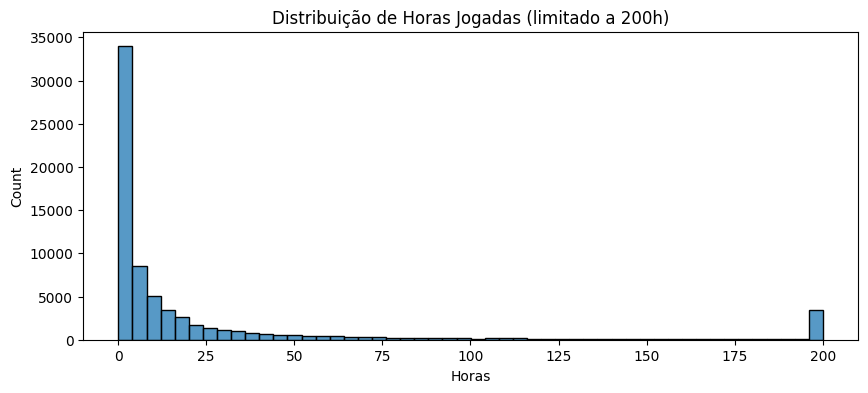

In [ ]:
print("Tipos de comportamento:", df['behavior'].unique()) # exibe os tipos de comportamento únicos presentes na base
print("\nNúmero de usuários únicos:", df['user_id'].nunique()) # mostra a quantidade total de usuários únicos cadastrados
print("Número de jogos únicos:", df['game_title'].nunique()) # mostra a quantidade total de jogos únicos no catálogo
print("Total de registros:", len(df)) # mostra o total geral de registros contidos no dataset
df_play = df[df['behavior'] == 'play'] # filtra o dataframe para conter apenas os registros de tempo de jogo

plt.figure(figsize=(10,4)) # define o tamanho da figura do gráfico de distribuição
sns.histplot(df_play['hours_played'].clip(upper=200), bins=50) # cria o histograma limitando visualmente em 200 horas para tratar outliers
plt.title('Distribuição de Horas Jogadas (limitado a 200h)') # define o título principal do gráfico gerado
plt.xlabel('Horas') # define o nome do eixo x do gráfico
plt.show() # renderiza e exibe o gráfico na tela

In [ ]:
df_play = df[df['behavior'] == 'play'].copy() # filtra os dados

df_play = df_play[df_play['hours_played'] <= 10000] # filtra para remover registros com mais de 10000 horas jogadas
df_play = df_play[df_play['hours_played'] > 0] # filtra para remover registros com zero horas jogadas

jogos_por_usuario = df_play.groupby('user_id')['game_title'].count() # conta a quantidade de jogos que cada usuario possui na base
usuarios_validos = jogos_por_usuario[jogos_por_usuario >= 5].index # filtra e guarda o indice dos usuarios que jogaram pelo menos 5 jogos

interacoes_por_jogo = df_play.groupby('game_title')['user_id'].count() # conta a quantidade de usuarios que jogaram cada jogo da base
jogos_validos = interacoes_por_jogo[interacoes_por_jogo >= 10].index # filtra e guarda o indice dos jogos que possuem pelo menos 10 interacoes

# aplica os dois filtros criados simultaneamente gerando um novo dataframe
df_filtrado = df_play[
    df_play['user_id'].isin(usuarios_validos) &
    df_play['game_title'].isin(jogos_validos)
].copy()

print(f"Registros após filtro:{len(df_filtrado)}") # exibe a quantidade total de registros restantes apos todos os filtros
print(f"Usuários:{df_filtrado['user_id'].nunique()}") # exibe a quantidade de usuarios unicos que restaram na base
print(f"Jogos:{df_filtrado['game_title'].nunique()}") # exibe a quantidade de jogos unicos que restaram na base

Registros após filtro:50986
Usuários:2435
Jogos:1053


In [ ]:
# função para converter as horas jogadas em notas de engajamento
def horas_para_engajamento(horas):
    # atribui nota 1 para menos de 1 hora jogada
    if horas < 1:
        return 1
    # atribui nota 2 para tempo entre 1 e 5 horas
    elif horas < 5:
        return 2
    # atribui nota 3 para tempo entre 5 e 20 horas
    elif horas < 20:
        return 3
    # atribui nota 4 para tempo entre 20 e 100 horas
    elif horas < 100:
        return 4
    # atribui nota 5 para quem jogou 100 horas ou mais
    else:
        return 5

# aplica a função mapeando a nova coluna de engajamento no dataframe filtrado
df_filtrado['engajamento'] = df_filtrado['hours_played'].apply(horas_para_engajamento)

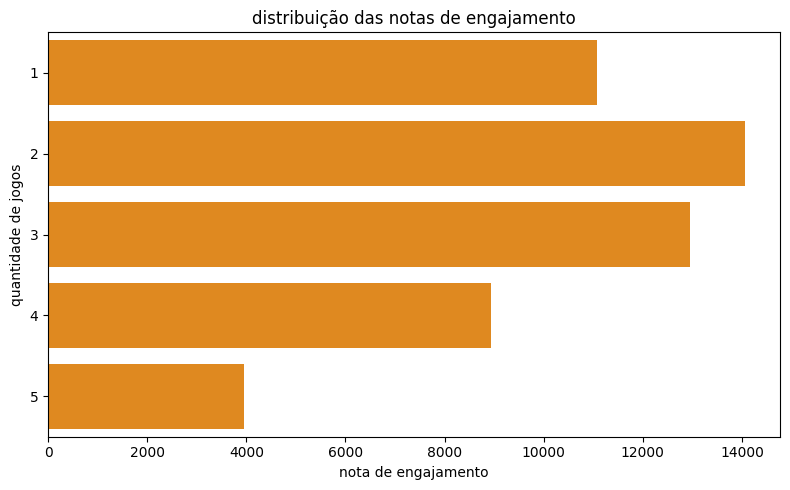

 
Numeros exatos:
engajamento
1    11076
2    14066
3    12945
4     8939
5     3960
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(8,5)) # define o tamanho da figura
sns.countplot(data=df_filtrado, y='engajamento', color='darkorange') # gera o grafico separadas por categoria
plt.title('distribuição das notas de engajamento') # define o título do gráfico de engajamento
plt.xlabel('nota de engajamento') # define o nome do eixo x
plt.ylabel('quantidade de jogos') # define o nome do eixo y
plt.tight_layout() # ajusta os espaçamentos para evitar bordas brancas desnecessárias
plt.show() # exibe o gráfico finalizado na tela

print(" ")
print("Numeros exatos:")
# exibe a contagem de registros de uma forma mais tecnica e facil de ler
print(df_filtrado['engajamento'].value_counts().sort_index())

In [ ]:
reader = Reader(rating_scale=(1, 5)) # define a escala das notas para a biblioteca surprise

# carrega os dados do dataframe filtrado usando o formato que planejei
data = Dataset.load_from_df(
    df_filtrado[['user_id', 'game_title', 'engajamento']],
    reader
)

# divide os dados em conjunto de treino e conjunto de teste usando 20 por cento para validação
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

In [ ]:
# inicializa o modelo knn baseline definindo e usando a similaridade de pearson
knn = KNNBaseline(k=20, sim_options={'name': 'pearson_baseline', 'user_based': True})

knn.fit(trainset) # treina o modelo knn utilizando o conjunto de dados de treino
preds_knn = knn.test(testset) # gera as predicoes de notas utilizando o conjunto de dados de teste

print("=== KNN Baseline ===") # exibe o titulo para identificar as metricas do modelo
rmse_knn = accuracy.rmse(preds_knn, verbose=False)# calcula as métricas de erro e ocultando a saída padrão
mae_knn = accuracy.mae(preds_knn, verbose=False)# calcula as métricas de erro e ocultando a saída padrão
print(f"RMSE: {rmse_knn:.4f}") # exibe o erro quadrático médio residual
print(f"MAE:  {mae_knn:.4f}") # exibe o erro absoluto médio

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
=== KNN Baseline ===
RMSE: 1.0494
MAE:  0.8430


In [ ]:
# inicializa o algoritmo svd definindo os hiperparametros do modelo
svd = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
svd.fit(trainset)# treina o modelo svd utilizando o conjunto de dados de treino
preds_svd = svd.test(testset) # gera as predicoes de notas utilizando o conjunto de dados de teste

print("=== SVD ===") # exibe o titulo para identificar as metricas do modelo
rmse_svd = accuracy.rmse(preds_svd, verbose=False) # calcula as métricas de erro ocultando a saída padrão
mae_svd = accuracy.mae(preds_svd, verbose=False) # calcula as métricas de erro ocultando a saída padrão
print(f"RMSE: {rmse_svd:.4f}") # exibe o erro quadrático médio residual
print(f"MAE:  {mae_svd:.4f}") # exibe o erro absoluto médio

=== SVD ===
RMSE: 1.0327
MAE:  0.8385


In [ ]:
# define a funcao para calcular a taxa
def hit_rate_at_k(predictions, k=10, threshold=3):
    user_est_true = defaultdict(list) # cria um dicionario para agrupar
    for uid, _, true_r, est, _ in predictions: # mapeia a lista de predicoes guardando o id
        user_est_true[uid].append((est, true_r))

    hits = 0 # inicializa o contador de acertos totais da base
    total = 0  # inicializa o contador de usuarios totais avaliados
    for uid, user_ratings in user_est_true.items(): # percorre cada usuario e suas respectivas listas de avaliacoes
        user_ratings.sort(key=lambda x: x[0], reverse=True) # ordena os itens do usuario com base na maior nota estimada para criar o ranking
        top_k = user_ratings[:k] # recorta apenas as top k recomendacoes de maior nota estimada
        hit = any(true_r >= threshold for (est, true_r) in top_k) # verifica se existe pelo menos um jogo relevante dentro do top k recortado
        if hit: # se encontrar pelo menos um acerto incrementa o contador de hits
            hits += 1
        total += 1 # incrementa o contador de usuarios avaliados na base

    # retorna a taxa final dividindo o total de hits pelo total de usuarios
    return hits / total

# executa a funcao criada passando as predicoes obtidas do modelo svd
hr_at_k = hit_rate_at_k(preds_svd, k=10, threshold=3)
# exibe o resultado do hit rate final convertido em porcentagem com uma casa decimal
print(f"Hit Rate@10: {hr_at_k:.4f} ({hr_at_k*100:.1f}%)")

Hit Rate@10: 0.7929 (79.3%)


In [ ]:
def recomendar_jogos(usuario_id, modelo, df, n=10): # define a funcao para gerar recomendacoes de jogos
    todos_jogos = df['game_title'].unique() # mapeia e guarda todos os titulos de jogos unicos
    jogos_do_usuario = df[df['user_id'] == usuario_id]['game_title'].tolist() # filtra e cria uma lista com os jogos que o usuario ja jogo
    jogos_nao_jogados = [j for j in todos_jogos if j not in jogos_do_usuario] # cria uma lista apenas com os jogos que o usuario ainda nao conhece

    previsoes = [modelo.predict(usuario_id, jogo) for jogo in jogos_nao_jogados] # calcula a predicao de nota para cada um dos jogos nao jogados pelo usuario
    previsoes.sort(key=lambda x: x.est, reverse=True) # ordena a lista de previsoes colocando as maiores notas estimadas primeiro

    print(f"\nTop {n} recomendações para o usuário {usuario_id}:\n") # exibe o titulo com a quantidade n de recomendacoes e o id do usuario
    for i, pred in enumerate(previsoes[:n], 1): # percorre a lista das top n predicoes gerando um ranking numerado
        print(f"{i}. {pred.iid} - engajamento previsto: {pred.est:.2f}") # exibe a posicao o nome do jogo e a nota de engajamento estimada com duas casas

usuario_teste = df_filtrado['user_id'].iloc[0] # pega o id do primeiro usuario que aparece na base filtrada para realizar o teste
recomendar_jogos(usuario_teste, svd, df_filtrado)# executa a funcao passando o usuario de teste o modelo svd e os dados filtrados


Top 10 recomendações para o usuário 151603712:

1. Football Manager 2013 - engajamento previsto: 4.05
2. Football Manager 2014 - engajamento previsto: 3.88
3. Football Manager 2012 - engajamento previsto: 3.76
4. Football Manager 2015 - engajamento previsto: 3.57
5. Grand Theft Auto V - engajamento previsto: 3.45
6. Football Manager 2011 - engajamento previsto: 3.43
7. Call of Duty Modern Warfare 2 - Multiplayer - engajamento previsto: 3.34
8. METAL GEAR SOLID V THE PHANTOM PAIN - engajamento previsto: 3.32
9. DARK SOULS II - engajamento previsto: 3.27
10. Counter-Strike Global Offensive - engajamento previsto: 3.25
